4.1 Creación y manipulación básica

In [26]:

frutas = {"manzana", "banana", "naranja", "kiwi", "mandarina", "pera"}
print("Conjunto inicial:", frutas)

# Agregar una nueva fruta.
frutas.add("mango")
print("Después de agregar 'mango':", frutas)

# Eliminar una fruta existente
frutas.remove("pera")
print("Después de eliminar 'pera':", frutas)

# Intentar agregar una fruta repetida
frutas.add("banana")
print("Después de intentar agregar 'banana' repetida:", frutas)

print("\nConjunto final:", frutas)
print("Explicación: los conjuntos no permiten elementos duplicados, por eso 'banana' no se añadió de nuevo.")

Conjunto inicial: {'naranja', 'banana', 'manzana', 'mandarina', 'pera', 'kiwi'}
Después de agregar 'mango': {'naranja', 'banana', 'mango', 'manzana', 'mandarina', 'pera', 'kiwi'}
Después de eliminar 'pera': {'naranja', 'banana', 'mango', 'manzana', 'mandarina', 'kiwi'}
Después de intentar agregar 'banana' repetida: {'naranja', 'banana', 'mango', 'manzana', 'mandarina', 'kiwi'}

Conjunto final: {'naranja', 'banana', 'mango', 'manzana', 'mandarina', 'kiwi'}
Explicación: los conjuntos no permiten elementos duplicados, por eso 'banana' no se añadió de nuevo.


4.2 Operaciones aplicadas a un caso real

Parte 6 – Reto Aplicado: Análisis de Texto
Analizador de palabras únicas

In [ ]:
import re

texto = input("Ingrese un párrafo de texto: ")
texto = texto.lower()
texto_limpio = re.sub(r"[^\w\s]", "", texto)

palabras = texto_limpio.split()
palabras_unicas = sorted(set(palabras))

print("Cantidad total de palabras:", len(palabras))
print("Número de palabras únicas:", len(palabras_unicas))
print("Lista ordenada de palabras únicas:", palabras_unicas)

In [ ]:
estudiantes_matematicas = {"Ana", "Luis", "Carlos", "María"}
estudiantes_fisica = {"Carlos", "María", "Sofía", "Pedro"}

ambas = estudiantes_matematicas & estudiantes_fisica
solo_matematicas = estudiantes_matematicas - estudiantes_fisica
solo_fisica = estudiantes_fisica - estudiantes_matematicas
union_total = estudiantes_matematicas | estudiantes_fisica
exclusivos_una_sola = estudiantes_matematicas ^ estudiantes_fisica

porcentaje_compartidos = (len(ambas) / len(union_total)) * 100

print("Estudiantes que cursan ambas asignaturas:", ambas)
print("Estudiantes que cursan solo matemáticas:", solo_matematicas)
print("Estudiantes que cursan solo física:", solo_fisica)
print("Unión total de estudiantes:", union_total)
print("Estudiantes exclusivamente en una sola asignatura:", exclusivos_una_sola)
print(f"Porcentaje de estudiantes compartidos entre ambas materias: {porcentaje_compartidos:.2f}%")

In [ ]:
def eliminar_duplicados(lista):
    vistos = set()
    resultado = []

    for elemento in lista:
        if elemento not in vistos:
            vistos.add(elemento)
            resultado.append(elemento)

    return resultado


# Ejemplo imprimible
lista_ejemplo = palabras + ["hola", "daniel", "python", "hola"]
print("Lista original:", lista_ejemplo)
print("Lista sin duplicados:", eliminar_duplicados(lista_ejemplo))

Parte 7 – Visualización: Diagramas de Venn

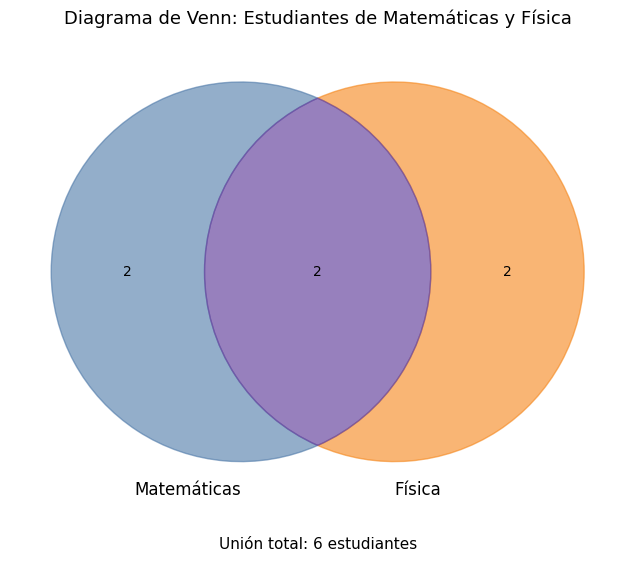

In [ ]:
import sys, subprocess
import matplotlib.pyplot as plt


est_mat = {"Ana", "Luis", "Carlos", "María"}
est_fis = {"Carlos", "María", "Sofía", "Pedro"}

# Operaciones internas de conjuntos
solo_mat = len(est_mat - est_fis)
solo_fis = len(est_fis - est_mat)
ambas = len(est_mat & est_fis)
union_total = est_mat | est_fis

# 3. GENERACIÓN DEL DIAGRAMA
plt.figure(figsize=(8, 6))
v = venn2(
    subsets=(solo_mat, solo_fis, ambas),
    set_labels=("Matemáticas", "Física")
)

if v.get_patch_by_id("10"):
    v.get_patch_by_id("10").set_color("#4C78A8")
    v.get_patch_by_id("10").set_alpha(0.6)
if v.get_patch_by_id("01"):
    v.get_patch_by_id("01").set_color("#F58518")
    v.get_patch_by_id("01").set_alpha(0.6)
if v.get_patch_by_id("11"):
    v.get_patch_by_id("11").set_color("#6B4BA2")
    v.get_patch_by_id("11").set_alpha(0.7)

plt.title("Diagrama de Venn: Estudiantes de Matemáticas y Física", fontsize=13, pad=12)
plt.text(0.5, -0.1, f"Unión total: {len(union_total)} estudiantes", 
         transform=plt.gca().transAxes, ha="center", fontsize=11)

plt.show()

Parte 8 – Sistema de Análisis de Conjuntos

In [ ]:
from functools import reduce
from matplotlib_venn import venn2, venn3

def leer_lista(mensaje):
    entrada = input(mensaje).strip()
    return [x.strip() for x in entrada.split(",") if x.strip()]

def ejecutar_operacion(conjuntos, opcion):
    if opcion == "1":  # Unión
        return reduce(lambda a, b: a | b, conjuntos), "Unión"
    elif opcion == "2":  # Intersección
        return reduce(lambda a, b: a & b, conjuntos), "Intersección"
    elif opcion == "3":  # Diferencia secuencial
        return reduce(lambda a, b: a - b, conjuntos), "Diferencia (secuencial)"
    elif opcion == "4":  # Diferencia simétrica
        return reduce(lambda a, b: a ^ b, conjuntos), "Diferencia simétrica"
    else:
        return None, None

def graficar_venn(nombres, conjuntos, titulo_operacion, resultado):
    n = len(conjuntos)

    if n == 2:
        A, B = conjuntos
        plt.figure(figsize=(7, 6))
        venn2([A, B], set_labels=nombres)
        plt.title(f"Diagrama de Venn ({titulo_operacion})")
        plt.text(
            0.5, -0.08,
            f"Resultado: {sorted(resultado)}",
            transform=plt.gca().transAxes,
            ha="center",
            fontsize=10
        )
        plt.show()

    elif n == 3:
        A, B, C = conjuntos
        plt.figure(figsize=(8, 7))
        venn3([A, B, C], set_labels=nombres)
        plt.title(f"Diagrama de Venn ({titulo_operacion})")
        plt.text(
            0.5, -0.08,
            f"Resultado: {sorted(resultado)}",
            transform=plt.gca().transAxes,
            ha="center",
            fontsize=10
        )
        plt.show()
    else:
        print("Visualización Venn disponible solo para 2 o 3 conjuntos.")

# --- Programa principal ---
print("=== Sistema de análisis con conjuntos ===")
k = int(input("¿Cuántas listas desea ingresar? (mínimo 2): ").strip())

if k < 2:
    print("Debe ingresar al menos 2 listas.")
else:
    nombres = []
    conjuntos = []

    for i in range(k):
        nombre = input(f"Nombre de la lista {i+1}: ").strip() or f"Lista {i+1}"
        lista = leer_lista(f"Ingrese elementos de '{nombre}' separados por coma: ")
        nombres.append(nombre)
        conjuntos.append(set(lista))

    print("\nConjuntos construidos:")
    for nombre, conj in zip(nombres, conjuntos):
        print(f"- {nombre}: {sorted(conj)}")

    print("\nElija una operación:")
    print("1) Unión")
    print("2) Intersección")
    print("3) Diferencia")
    print("4) Diferencia simétrica")

    opcion = input("Opción (1-4): ").strip()
    resultado, titulo = ejecutar_operacion(conjuntos, opcion)

    if resultado is None:
        print("Opción inválida.")
    else:
        print(f"\nOperación: {titulo}")
        print(f"Resultado ({len(resultado)} elementos): {sorted(resultado)}")
        graficar_venn(nombres, conjuntos, titulo, resultado)